In [8]:
import jax.random as jr
import lineax as lx
import jax.numpy as jnp
import jax
jax.config.update("jax_enable_x64", True)

# matrix = jr.normal(jr.PRNGKey(0), (30, 30))
matlen = 3

# make tridiagonal matrix
matrix = jnp.eye(matlen)
matrix = matrix.at[jnp.arange(matlen - 1), jnp.arange(1, matlen)].set(-1)
matrix = matrix.at[jnp.arange(1, matlen), jnp.arange(matlen - 1)].set(-1)

matrix_leading_diag = matrix[jnp.arange(matlen), jnp.arange(matlen)]
matrix_upper_diag = matrix[jnp.arange(matlen - 1), jnp.arange(1, matlen)]
matrix_lower_diag = matrix[jnp.arange(1, matlen), jnp.arange(matlen - 1)]

vector = jr.normal(jr.PRNGKey(1), (matlen,))

operator = lx.MatrixLinearOperator(matrix)
tridiag_operator = lx.TridiagonalLinearOperator(matrix_leading_diag, matrix_upper_diag, matrix_lower_diag)

In [9]:
solution = lx.linear_solve(operator, vector)
print(f"A=\n{matrix}\nb={vector}\nx={solution.value}")

A=
[[ 1. -1.  0.]
 [-1.  1. -1.]
 [ 0. -1.  1.]]
b=[-1.18428442 -0.11617041  0.17269028]
x=[-0.05651987  1.12776455  1.30045483]


In [10]:
solution = lx.linear_solve(tridiag_operator, vector, solver=lx.Tridiagonal())
print(f"A=\n{matrix}\nb={vector}\nx={solution.value}")

A=
[[ 1. -1.  0.]
 [-1.  1. -1.]
 [ 0. -1.  1.]]
b=[-1.18428442 -0.11617041  0.17269028]
x=[-0.05651987  1.12776455  1.30045483]


In [11]:
# %timeit lx.linear_solve(operator, vector).value.block_until_ready()

In [12]:
# %timeit lx.linear_solve(tridiag_operator, vector,).value.block_until_ready()

# Cubic spline

In [ ]:
import jax
import jax.numpy as jnp

@jax.jit
def build_interp_grid(x, y):
    diag = jnp.zeros(x.size)
    ud = jnp.zeros(x.size - 1)
    ld = jnp.zeros(x.size - 1)

    b = jnp.zeros(x.size)

    dx = jnp.diff(x)
    slope = jnp.diff(y) / dx

    # Fill interior
    diag = diag.at[1:-1].set(2 * (dx[:-1] + dx[1:]))
    ud = ud.at[1:].set(dx[:-1])
    ld = ld.at[:-1].set(dx[1:])

    b = b.at[1:-1].set(3 * (dx[1:] * slope[:-1] + dx[:-1] * slope[1:]))

    # Left BC
    diag = diag.at[0].set(dx[1])
    d = x[2] - x[0]
    ud = ud.at[0].set(d)
    b = b.at[0].set(
        ((dx[0] + 2*d) * dx[1] * slope[0] +
            dx[0]**2 * slope[1]) / d
        )

    # Right BC
    diag = diag.at[-1].set(dx[-2])
    d = x[-1] - x[-3]
    ld = ld.at[-1].set(d)
    b = b.at[-1].set((dx[-1]**2 * slope[-2] +
             (2*d + dx[-1]) * dx[-2] * slope[-1]) / d)

    return diag, ud, ld, b

@jax.jit
def get_spline_coefficients(x, y):
    diag, ud, ld, b = build_interp_grid(x, y)
    tridiag_operator = lx.TridiagonalLinearOperator(diag, ld, ud)
    dydx = lx.linear_solve(tridiag_operator, b, solver=lx.Tridiagonal()).value

    coefficients = jnp.zeros((x.size, 4))

    dx = jnp.diff(x)
    slope = jnp.diff(y) / dx

    t = (dydx[:-1] + dydx[1:] - 2 * slope) / dx

    coeff1 = dydx
    coeff2 = (slope - dydx[:-1]) / dx - t
    coeff3 = t / dx

    coefficients = coefficients.at[:, 0].set(y)
    coefficients = coefficients.at[:, 1].set(coeff1)
    coefficients = coefficients.at[:-1, 2].set(coeff2)
    coefficients = coefficients.at[:-1, 3].set(coeff3)
    return coefficients

# @jax.jit
def evaluate_spline(x, coefficients, x_eval):
    idx = jnp.searchsorted(x, x_eval, side="right") - 1
    idx = jnp.clip(idx, 0, x.size - 2)

    dx = x_eval - x[idx]
    coeffs = coefficients[idx]

    return coeffs[:, 0] + coeffs[:, 1] * dx + coeffs[:, 2] * dx**2 + coeffs[:, 3] * dx**3
    # return coeffs[:, 3] + coeffs[:, 2] * dx + coeffs[:, 1] * dx**2 + coeffs[:, 0] * dx**3

In [213]:
import matplotlib.pyplot as plt
npoint = 100

x = jnp.linspace(0, 10, 100)**2
y = jnp.sin(x * 0.1)**3
x_ev = jnp.linspace(0, x[-1], 12345)

# diag, ud, ld, b = build_interp_grid(x, y)
coefficients = get_spline_coefficients(x, y)
y_spl = evaluate_spline(x, coefficients, x_ev)

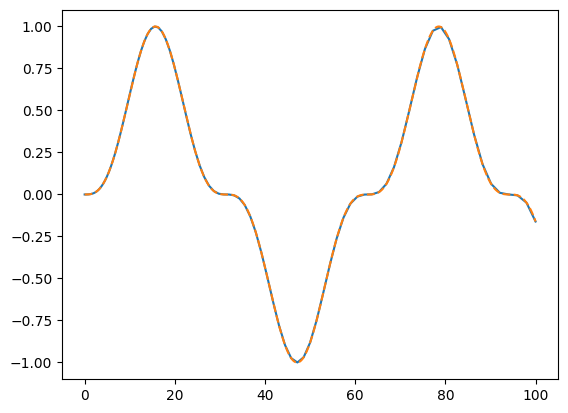

In [214]:
plt.plot(x, y)
plt.plot(x_ev, y_spl, '--')

In [217]:
x = jax.vmap(jnp.linspace, in_axes=(None, 0, None))(0, jnp.linspace(8, 10, 30), npoint)**2
y = jnp.sin(x * 0.1)
x_ev = jnp.linspace(0, 8**2, 12345)

# diag, ud, ld, b = build_interp_grid(x, y)

coefficients = jax.vmap(get_spline_coefficients, in_axes=(0, 0))(x, y)
y_spl = jax.vmap(evaluate_spline, in_axes=(0, 0, None))(x, coefficients, x_ev)

# Variable length solver

In [219]:
from jax.random import PRNGKey

In [899]:
key = PRNGKey(0)

nspl = 10
nmax = 100
lengths = jax.random.randint(key, (nspl,), 10, nmax)

x = jax.vmap(jnp.linspace, in_axes=(None, 0, None))(0, jnp.linspace(8, 10, nspl), nmax)**2
for i in range(nspl):
    l_here = lengths[i]
    x = x.at[i, l_here:].set(jnp.nan)

y = jnp.sin(x * 0.1) ** 4


In [ ]:
from functools import partial

@partial(jax.jit, static_argnums=(3,))
def build_interp_grid_variable(x, y, len, maxlen):
    diag = jnp.full(maxlen, 1.0)
    ud = jnp.full(maxlen - 1, 0.0)
    ld = jnp.full(maxlen - 1, 0.0)

    b = jnp.full(maxlen , 0.0)

    dx = jnp.diff(x)
    slope = jnp.diff(y) / dx

    # Fill interior
    diag = jax.lax.dynamic_update_slice(diag, 2 * (dx[:-1] + dx[1:]), (1, ))
    ud = jax.lax.dynamic_update_slice(ud, dx[:-1], (1, ))
    ld = jax.lax.dynamic_update_slice(ld, dx[1:], (0, ))
    b = jax.lax.dynamic_update_slice(b, 3 * (dx[1:] * slope[:-1] + dx[:-1] * slope[1:]), (1, ))

    # Left BC
    diag = jax.lax.dynamic_update_index_in_dim(diag, dx[1], 0, 0)
    d = x[2] - x[0]
    ud = jax.lax.dynamic_update_index_in_dim(ud, d, 0, 0)
    b = jax.lax.dynamic_update_index_in_dim(b, ((dx[0] + 2*d) * dx[1] * slope[0] +
            dx[0]**2 * slope[1]) / d, 0, 0)

    # Right BC
    diag = jax.lax.dynamic_update_index_in_dim(diag, dx[len-3], len-1, 0)
    d = x[len-1] - x[len-3]
    ld = jax.lax.dynamic_update_index_in_dim(ld, d, len-2, 0)
    b = jax.lax.dynamic_update_index_in_dim(b, (dx[len-2]**2 * slope[len-3] +
             (2*d + dx[len-2]) * dx[len-3] * slope[len-2]) / d, len-1, 0)

    # Pad missing entries to avoid NaNs in the linear solve
    diag = jnp.where(jnp.arange(maxlen) < len, diag, 1.0)
    ud = jnp.where(jnp.arange(maxlen - 1) < len - 1, ud, 0.0)
    ld = jnp.where(jnp.arange(maxlen - 1) < len - 1, ld, 0.0)

    b = jnp.where(jnp.arange(maxlen) < len, b, 0.0)

    return diag, ud, ld, b

@partial(jax.jit, static_argnums=(3,))
def get_spline_coefficients_variable(x, y, len, maxlen):
    diag, ud, ld, b = build_interp_grid_variable(x, y, len, maxlen)
    tridiag_operator = lx.TridiagonalLinearOperator(diag, ld, ud)

    dydx = lx.linear_solve(tridiag_operator, b, solver=lx.Tridiagonal()).value

    coefficients = jnp.full((maxlen, 4), jnp.nan)

    dx = jnp.diff(x)
    slope = jnp.diff(y) / dx

    t = (dydx[:-1] + dydx[1:] - 2 * slope) / dx

    coeff1 = dydx
    coeff2 = (slope - dydx[:-1]) / dx - t
    coeff3 = t / dx

    coefficients = coefficients.at[:, 0].set(y)
    coefficients = coefficients.at[:, 1].set(coeff1)
    coefficients = coefficients.at[:-1, 2].set(coeff2)
    coefficients = coefficients.at[:-1, 3].set(coeff3)
    return coefficients

In [913]:
coefficients = jax.vmap(get_spline_coefficients_variable, in_axes=(0, 0, 0, None))(x, y, lengths, nmax)

In [915]:
y_spl = jax.vmap(evaluate_spline, in_axes=(0, 0, None))(x, coefficients, x_ev)

Array(64, dtype=int64)

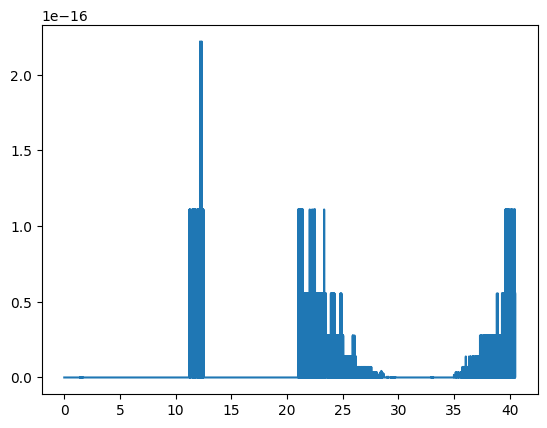

In [916]:
from scipy.interpolate import CubicSpline
insp_ind = 24
truth_spl = CubicSpline(x[insp_ind, :lengths[insp_ind]], y[insp_ind, :lengths[insp_ind]])
x_ev_clipped = x_ev[x_ev <= x[insp_ind, lengths[insp_ind]-1]]
y_spl_clipped = evaluate_spline(x[insp_ind], coefficients[insp_ind], x_ev_clipped)

# plt.plot(x[0], y[0])
# plt.plot(x_ev, y_spl[0])
# plt.plot(x_ev_clipped, truth_spl(x_ev_clipped), '--')

plt.plot(x_ev_clipped, jnp.abs(y_spl_clipped - truth_spl(x_ev_clipped)))
lengths[insp_ind]